
#  Experimento: Muestras

### Tiempo de entrenamiento de SoM (somJ) vs MiniSom en función del nº de muestras con 5-fold CV

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold

from somJ.som import SoM
from minisom import MiniSom
import somJ.config as config
from functions import load_dataset

2025-05-26 19:30:24.849740: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 19:30:24.850300: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 19:30:24.852958: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 19:30:24.859782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748284224.870826 2494976 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748284224.87

In [ ]:
AJUSTADO = False
sample_sizes = [1000, 5000, 10000, 20000, 40000]
fixed_dim    = 784
epochs       = 3
som_shape    = int(np.sqrt(config.TOTAL_NODES))
n_splits     = 5

# Carga y normalización
X_all, _ = load_dataset("MNIST")
scaler   = MinMaxScaler()
X_all    = scaler.fit_transform(X_all)

# Para guardar resultados de cada fold
times_somJ    = {n: [] for n in sample_sizes}
times_minisom = {n: [] for n in sample_sizes}

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for n in sample_sizes:
    print(f"\n=== Muestras: {n} ===")
    X_sample = X_all[:n]
    
    # 5-fold splits
    for fold, (train_idx, _) in enumerate(kf.split(X_sample), 1):
        X_train = X_sample[train_idx]
        print(f" Fold {fold}/{n_splits}", end='… ')
        
        # --- SoM (somJ) ---
        som = SoM(
            method=config.INIT_METHOD,
            data=X_train,
            total_nodes=config.TOTAL_NODES
        )
        t0 = time.time()
        som.train(
            train_data=X_train,
            learn_rate=config.LEARNING_RATE,
            sigma=config.SIGMA,
            prog_bar=False
        )
        times_somJ[n].append(time.time() - t0)
        
        # --- MiniSom ---
        minisom = MiniSom(
            som_shape, som_shape, fixed_dim,
            sigma=config.SIGMA,
            learning_rate=config.LEARNING_RATE
        )
        t0 = time.time()

        for _ in range(epochs):
            minisom.train_batch(X_train, len(X_train))
        times_minisom[n].append(time.time() - t0)
        
        print("OK")

# Calculamos medias y desviaciones
mean_somJ    = []
std_somJ     = []
mean_minisom = []
std_minisom  = []

for n in sample_sizes:
    arr1 = np.array(times_somJ[n])
    arr2 = np.array(times_minisom[n])
    mean_somJ.append(arr1.mean());    std_somJ.append(arr1.std(ddof=1))
    mean_minisom.append(arr2.mean()); std_minisom.append(arr2.std(ddof=1))
    print(f"{n:6d} → SoM mean={arr1.mean():.3f}s ±{arr1.std(ddof=1):.3f}, "
          f"MiniSom mean={arr2.mean():.3f}s ±{arr2.std(ddof=1):.3f}")





=== Muestras: 1000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 5000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 10000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 20000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 40000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK
  1000 → SoM mean=1.393s ±0.108, MiniSom mean=0.473s ±0.019
  5000 → SoM mean=6.780s ±0.193, MiniSom mean=2.471s ±0.074
 10000 → SoM mean=14.449s ±0.956, MiniSom mean=4.729s ±0.288
 20000 → SoM mean=28.512s ±1.661, MiniSom mean=9.041s ±0.420
 40000 → SoM mean=56.849s ±1.073, MiniSom mean=18.064s ±0.796


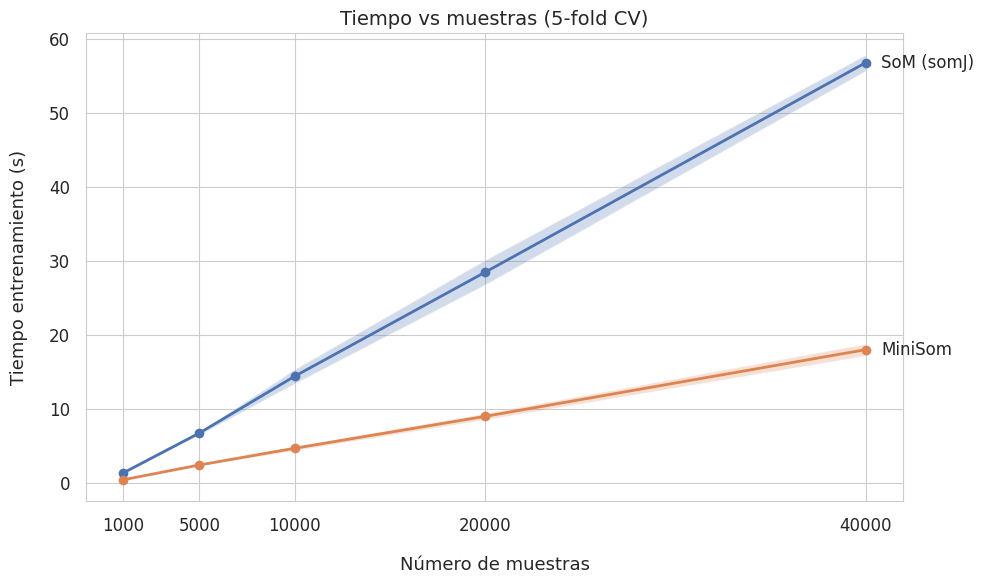

In [8]:
# --- Gráfica al estilo profesional ---

sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=2)
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)

fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)

# SoM (somJ)
ax.plot(sample_sizes, mean_somJ, marker='o', linewidth=2, label='SoM (somJ)')
ax.fill_between(sample_sizes,
                np.array(mean_somJ) - np.array(std_somJ),
                np.array(mean_somJ) + np.array(std_somJ),
                alpha=0.25)

# MiniSom
ax.plot(sample_sizes, mean_minisom, marker='o', linewidth=2, label='MiniSom')
ax.fill_between(sample_sizes,
                np.array(mean_minisom) - np.array(std_minisom),
                np.array(mean_minisom) + np.array(std_minisom),
                alpha=0.25)

# Direct labels al final de cada curva
ax.text(sample_sizes[-1]*1.02, mean_somJ[-1],
        'SoM (somJ)', va='center')
ax.text(sample_sizes[-1]*1.02, mean_minisom[-1],
        'MiniSom', va='center')

# Escala lineal y ticks proporcionales
ax.set_xscale('linear')
ax.set_xticks(sample_sizes)

# Padding en ticks y etiquetas
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

ax.set_xlabel('Número de muestras')
ax.set_ylabel('Tiempo entrenamiento (s)')
ax.set_title(f'Tiempo vs muestras (5-fold CV){" - ajustado" if AJUSTADO else ""}')

plt.tight_layout()
plt.show()